In [1]:
import os
import json
import random
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import rasterio
from rasterio.windows import Window
from rasterio.mask import mask

from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import zoom
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from data_loader import (
    load_dem, load_infiltration_map, load_landuse_map, load_manila_mask, load_all_flood_maps, get_raster_stats, print_raster_stats,
    load_all_rainfall_scenarios, get_rainfall_stats, print_rainfall_stats, visualize_raster, visualize_flood_maps_grid, manila_path_shape_load_all_flood_maps
)

RANDOM_SEED = 42
NUM_TRAIN = 15
NUM_TEST = 5
NUM_SCENARIO = 50
PATCH_SIZE = 4
BATCH_SIZE = 1024
NUM_WORKERS = 4     
PIN_MEMORY = False

In [2]:
repo_root = os.getcwd()
gmm_no_manila_path = os.path.join(repo_root, "COP-30m-GMM-ManilaMaskOut")
manila_path = os.path.join(repo_root, "COP-30m-ManilaOnly")
rs_path = os.path.join(repo_root, "mm_hr_scenarios")

# Loading Data

## Train Data


--- Loading DEM ---
DEM loaded: shape (1224, 1125), dtype float32

Statistics for: DEM
Shape:         (1224, 1125)
Dtype:         float32
Min value:     -4.9004
Max value:     466.3908
Mean value:    44.9711
Std dev:       71.0011
Valid pixels:  1,273,959 / 1,377,000


--- Loading Infiltration Map ---
Infiltration map loaded: shape (1224, 1125), dtype float64

Statistics for: Infiltration Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     0.0000
Max value:     3.6847
Mean value:    0.5198
Std dev:       0.9750
Valid pixels:  1,273,959 / 1,377,000


--- Loading Landuse Map ---
Landuse map loaded: shape (1224, 1125), dtype float64

Statistics for: Landuse Map
Shape:         (1224, 1125)
Dtype:         float64
Min value:     1.0000
Max value:     11.0000
Mean value:    4.8709
Std dev:       2.5478
Valid pixels:  1,273,959 / 1,377,000


--- Loading Flood Maps (Ground Truth) ---
Flood map RS1 loaded: shape (1224, 1125), dtype float64
Flood map RS2 loaded: shape (1224, 11

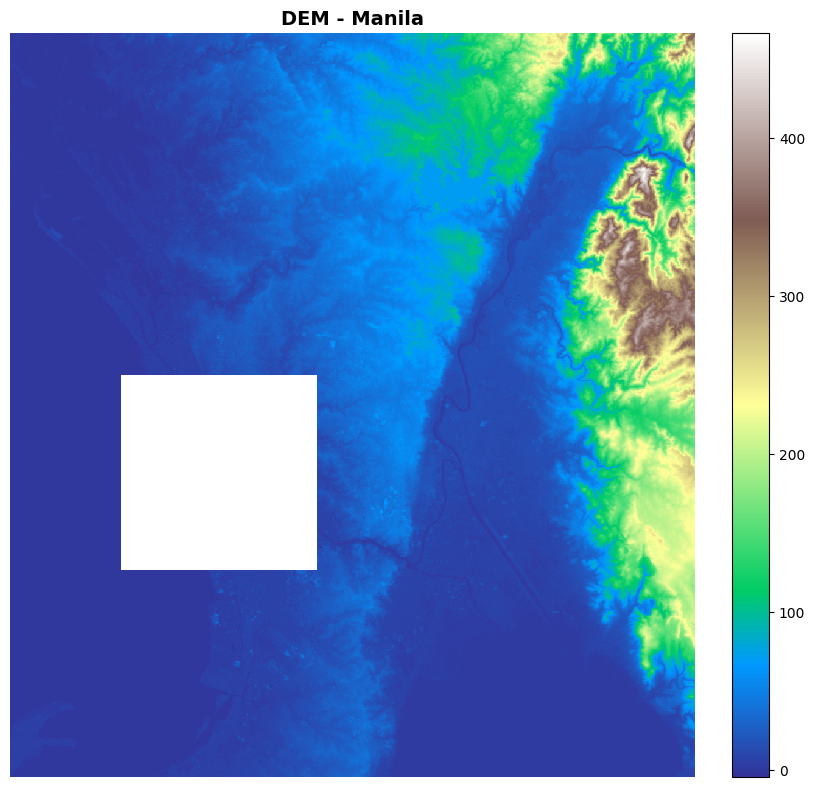

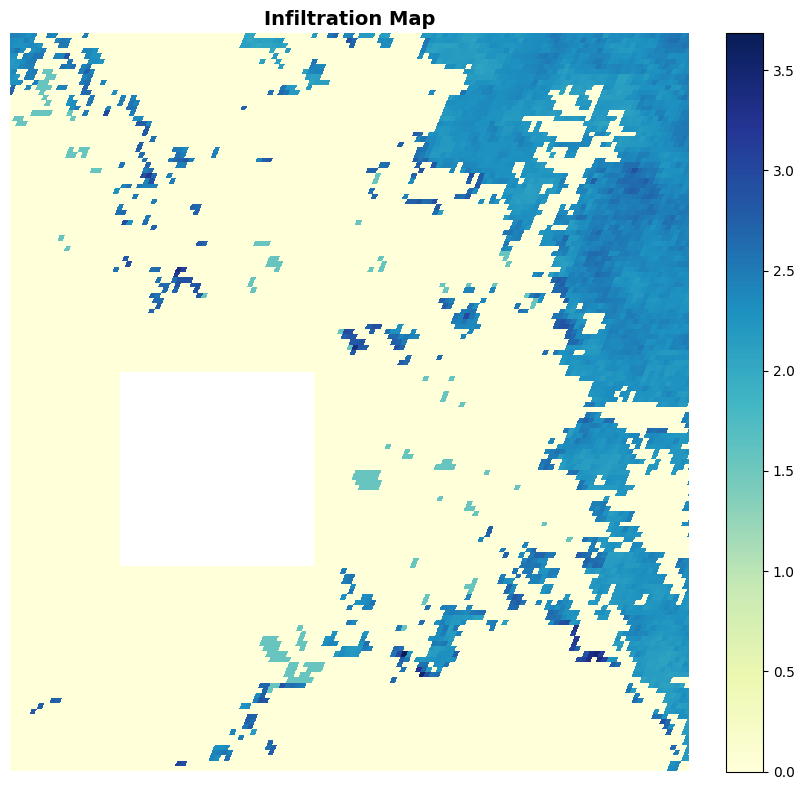

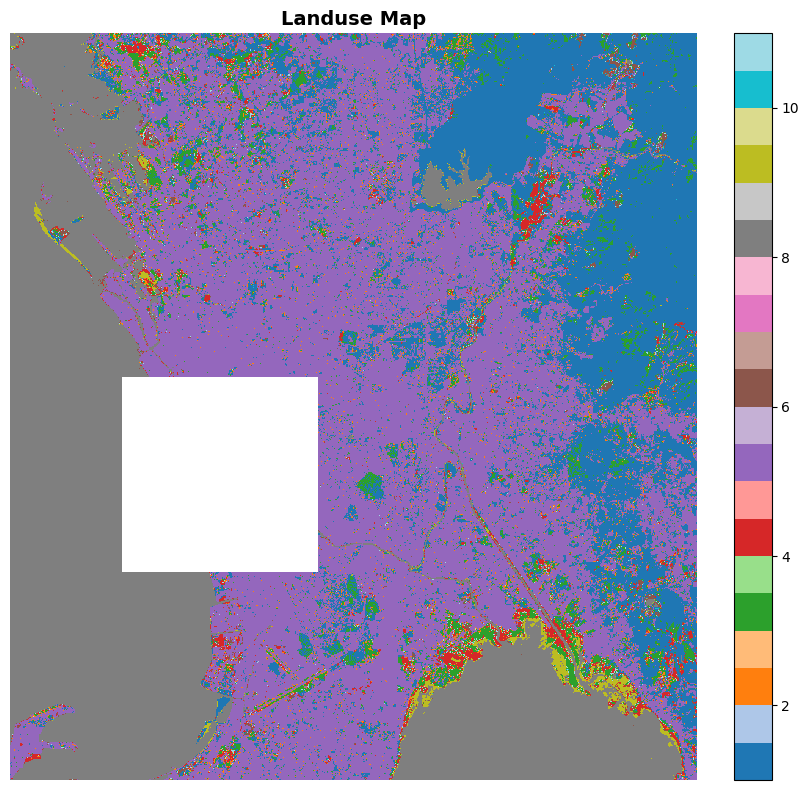

In [ ]:
print("\n--- Loading DEM ---")
dem_path = os.path.join(gmm_no_manila_path, "by_box", "greater_mm_bbox_dem_cop_noManila_box.tif")
if os.path.exists(dem_path):
    train_dem_data, train_dem_meta = load_dem(dem_path)
    dem_stats = get_raster_stats(train_dem_data, "DEM")
    print_raster_stats(dem_stats)
else:
    print(f"WARNING: DEM file not found at {dem_path}")

fig1 = visualize_raster(train_dem_data, title="DEM - Manila", cmap='terrain')


# Load Infiltration Map
print("\n--- Loading Infiltration Map ---")
infilt_path = os.path.join(gmm_no_manila_path, "by_box", "GM_Infilt_noManila_box.tif")
if os.path.exists(infilt_path):
    train_infilt_data, train_infilt_meta = load_infiltration_map(infilt_path)
    infilt_stats = get_raster_stats(train_infilt_data, "Infiltration Map")
    print_raster_stats(infilt_stats)
else:
    print(f"WARNING: Infiltration file not found at {infilt_path}")
    infilt_data = None
fig2 = visualize_raster(train_infilt_data, title="Infiltration Map", cmap='YlGnBu')

print("\n--- Loading Landuse Map ---")
landuse_path = os.path.join(gmm_no_manila_path, "by_box", "GM_LU_noManila_box.tif")
if os.path.exists(landuse_path):
    train_landuse_data, landuse_meta = load_landuse_map(landuse_path)
    landuse_stats = get_raster_stats(train_landuse_data, "Landuse Map")
    print_raster_stats(landuse_stats)
else:
    print(f"WARNING: Landuse file not found at {landuse_path}")
    landuse_data = None

fig3 = visualize_raster(train_landuse_data, title="Landuse Map", cmap='tab20')

# Load all flood maps
print("\n--- Loading Flood Maps (Ground Truth) ---")
fm_path = os.path.join(gmm_no_manila_path, "by_box")
flood_maps_train, flood_metadata = load_all_flood_maps(fm_path, num_scenarios=NUM_SCENARIO)

if len(flood_maps_train) > 0:
    print(f"\nFlood maps successfully loaded: {len(flood_maps_train)}")
    
    if len(flood_maps_train) >= NUM_SCENARIO:
        flood_stats = get_raster_stats(flood_maps_train[-1], "Flood Map RS20")
else:
    print("WARNING: No flood maps loaded!")

fig4 = visualize_flood_maps_grid(flood_maps=flood_maps_train,scenario_ids=list(range(1, 51)),figsize=(25, 20),ncols=5,cmap='terrain')
print_raster_stats(flood_stats)



## Test Data

In [ ]:
# Load DEM
print("\n--- Loading DEM ---")
dem_path = os.path.join(manila_path, "exp-des-4", "manila_bbox_dem_cop.tif")
if os.path.exists(dem_path):
    dem_data_test, dem_meta = load_dem(dem_path)
    dem_stats = get_raster_stats(dem_data_test, "DEM")
    print_raster_stats(dem_stats)
else:
    print(f"WARNING: DEM file not found at {dem_path}")
    dem_data_test = None

fig1 = visualize_raster(dem_data_test, title="DEM - Manila", cmap='terrain')

# Load Infiltration Map
print("\n--- Loading Infiltration Map ---")
infilt_path = os.path.join(manila_path, "exp-des-4", "GM_Infilt_Manila_box.tif")
if os.path.exists(infilt_path):
    infilt_data_test, infilt_meta = load_infiltration_map(infilt_path)
    infilt_stats = get_raster_stats(infilt_data_test, "Infiltration Map")
    print_raster_stats(infilt_stats)
else:
    print(f"WARNING: Infiltration file not found at {infilt_path}")
    infilt_data_test = None
fig2 = visualize_raster(infilt_data_test, title="Infiltration Map", cmap='YlGnBu')

# Load Landuse Map
print("\n--- Loading Landuse Map ---")
landuse_path =  os.path.join(manila_path, "exp-des-4", "GM_LU_Manila_box.tif")
if os.path.exists(landuse_path):
    landuse_data_test, landuse_meta = load_landuse_map(landuse_path)
    landuse_stats = get_raster_stats(landuse_data_test, "Landuse Map")
    print_raster_stats(landuse_stats)
else:
    print(f"WARNING: Landuse file not found at {landuse_path}")
    landuse_data_test = None
    
fig3 = visualize_raster(landuse_data_test, title="Landuse Map", cmap='tab20')

# Load all flood maps
print("\n--- Loading Flood Maps (Ground Truth) ---")
fm_path = os.path.join(manila_path, "exp-des-4")
flood_maps_test, flood_metadata = manila_path_shape_load_all_flood_maps(fm_path, num_scenarios=NUM_SCENARIO)

if len(flood_maps_test) > 0:
    print(f"\nFlood maps successfully loaded: {len(flood_maps_test)}")
    
    if len(flood_maps_test) >= NUM_SCENARIO:
        flood_stats = get_raster_stats(flood_maps_test[-1], "Flood Map RS20")
else:
    print("WARNING: No flood maps loaded!")

fig4 = visualize_flood_maps_grid(flood_maps=flood_maps_test,scenario_ids=list(range(1, 51)),figsize=(25, 20),ncols=5,cmap='terrain')
print_raster_stats(flood_stats)

## Manila Mask

In [ ]:
print("\n--- Loading Manila Mask ---")
mask_path = os.path.join(manila_path, "manila_box_3857.tif")
if os.path.exists(mask_path):
    mask_data, mask_meta = load_manila_mask(mask_path)
    mask_stats = get_raster_stats(mask_data, "Mask")
    print_raster_stats(mask_stats)
else:
    print(f"WARNING: Mask file not found at {mask_path}")

fig1 = visualize_raster(mask_data, title="Manila Mask", cmap='terrain')

In [ ]:
print("\n" + "="*70)
print("PHASE 1.3: MANILA BOX MASK PROCESSING")
print("="*70)

from scipy.ndimage import zoom

# Current mask shape vs required shape
print(f"\nCurrent mask shape: {mask_data.shape}")
# Resize mask to match raster dimensions
target_shape = (1224, 1125)
zoom_factors = (target_shape[0] / mask_data.shape[0], 
                target_shape[1] / mask_data.shape[1])
print(f"\nZoom factors: {zoom_factors}")
mask_resized = zoom(mask_data, zoom_factors, order=0)  # order=0 = nearest neighbor
print(f"Resized mask shape: {mask_resized.shape}")

# Verify values remain binary
unique_values = np.unique(mask_resized)
print(f"Unique values in resized mask: {unique_values}")

# Statistics
mask_resized_stats = get_raster_stats(mask_resized, "Manila Mask (Resized)")
print_raster_stats(mask_resized_stats)
manila_box_mask = mask_resized

In [ ]:
print("\n  Variables ready for Phase 2:")
print(f"  - train_dem_data (train): {train_dem_data.shape}")
print(f"  - train_infilt_data (train): {train_infilt_data.shape}")
print(f"  - train_landuse_data (train): {train_landuse_data.shape}")
print(f"  - dem_data_test (test): {dem_data_test.shape}")
print(f"  - infilt_data_test (test): {infilt_data_test.shape}")
print(f"  - landuse_data_test (test): {landuse_data_test.shape}")
print(f"  - flood_maps_train (train): {len(flood_maps_train)} maps")
print(f"  - flood_maps_test (test): {len(flood_maps_test)} maps")


# Data Preprocessing

In [ ]:
from data_preprocessing import preprocess_spatial_data
import matplotlib.pyplot as plt

preprocessed = preprocess_spatial_data(
    train_dem=train_dem_data,
    train_infilt=train_infilt_data,
    train_landuse=train_landuse_data,
    test_dem=dem_data_test,
    test_infilt=infilt_data_test,
    test_landuse=landuse_data_test,
    mask=manila_box_mask,
    target_shape=(1152, 1152),      
    nodata_method='interpolate', 
    norm_method='minmax'  
)

In [ ]:
# Extract preprocessed data
train_dem_preprocessed = preprocessed['train']['dem']
train_infilt_preprocessed = preprocessed['train']['infiltration']
train_landuse_preprocessed = preprocessed['train']['landuse']
test_dem_preprocessed = preprocessed['test']['dem']
test_infilt_preprocessed = preprocessed['test']['infiltration']
test_landuse_preprocessed = preprocessed['test']['landuse']
mask_preprocessed = preprocessed['mask']

print(f"  - train_dem_preprocessed: {train_dem_preprocessed.shape}")
print(f"  - train_infilt_preprocessed: {train_infilt_preprocessed.shape}")
print(f"  - train_landuse_preprocessed: {train_landuse_preprocessed.shape}")
print(f"  - test_dem_preprocessed: {test_dem_preprocessed.shape}")
print(f"  - test_infilt_preprocessed: {test_infilt_preprocessed.shape}")
print(f"  - test_landuse_preprocessed: {test_landuse_preprocessed.shape}")
print(f"  - mask_preprocessed: {mask_preprocessed.shape}")
print(f"  - flood_maps_train: {len(flood_maps_train)} scenarios")
print(f"  - flood_maps_test: {len(flood_maps_test)} scenarios")


# Rainfall 

In [ ]:
print("LOADING RAINFALL SCENARIOS")
# Load rainfall scenarios
rainfall_scenarios = load_all_rainfall_scenarios(rs_path)

if len(rainfall_scenarios) > 0:
    print(f"\nRainfall scenarios successfully loaded: {len(rainfall_scenarios)}")
else:
    print("WARNING: No rainfall scenarios loaded!")

In [ ]:
from rainfall import preprocess_rainfall_sequences, visualize_rainfall_sequences, visualize_conditioning_vectors

# Preprocess rainfall sequences
rainfall_results = preprocess_rainfall_sequences(rainfall_scenarios=rainfall_scenarios, norm_method='global_max', info_csv_path='./info.csv')

# Output now includes:
rainfall_results['conditioning_vectors']  
rainfall_results['encoding_info']      

# Ground Truth (Flood Maps)

In [ ]:
from flood_maps import categorize_flood_maps, resize_flood_maps, visualize_categorized_maps  

# Create masks (train = GMM outskirts, test = Manila core)
train_mask = 1 - mask_preprocessed  # Inverse of Manila box
test_mask = mask_preprocessed       # Manila box

flood_maps_train_resized = resize_flood_maps(flood_maps=flood_maps_train, target_shape=(1152, 1152), split_name='Train')
flood_maps_test_resized = resize_flood_maps(flood_maps=flood_maps_test, target_shape=(1152, 1152), split_name='Test')

In [ ]:
# Categorize flood maps
categorization_results = categorize_flood_maps(
    train_flood_maps=flood_maps_train_resized,      
    test_flood_maps=flood_maps_test_resized,        
    train_mask=train_mask,
    test_mask=test_mask,
    patch_size=PATCH_SIZE,                          
    categorization_method='majority_vote',   
    class_thresholds=[0.15, 0.24, 0.46, 0.68]
)

In [ ]:
fig1 = visualize_categorized_maps(categorization_results, original_flood_maps=flood_maps_train, split='train', num_scenarios=1)
fig2 = visualize_categorized_maps(categorization_results, original_flood_maps=flood_maps_test, split='test', num_scenarios=1)

# Rainfall-based Partitioning

In [ ]:
from data_splitting import split_spatial_data

split_results = split_spatial_data( 
    categorization_results=categorization_results,
    preprocessed_spatial=preprocessed, rainfall_results=rainfall_results,
    train_ratio=0.70, random_seed=42, patch_size=PATCH_SIZE
)

X_train_spatial = split_results['train']['spatial_patches']      
X_train_rainfall = split_results['train']['rainfall_sequences']  
y_train = split_results['train']['labels']                      

X_test_spatial = split_results['test']['spatial_patches']        
X_test_rainfall = split_results['test']['rainfall_sequences']     
y_test = split_results['test']['labels']                         

print(f"\nFinal Dataset Shapes:")
print(f"  Train: {X_train_spatial.shape[0]:,} samples")
print(f"  Test: {X_test_spatial.shape[0]:,} samples")

# Patchify

In [ ]:
from patchify import extract_vit_patches, get_data_loader_ready
vit_results = extract_vit_patches(split_results=split_results,patch_size=PATCH_SIZE)

train_data, test_data = get_data_loader_ready(vit_results)
X_train_spatial, X_train_rainfall, X_train_conditioning, y_train = train_data
X_test_spatial, X_test_rainfall, X_test_conditioning, y_test = test_data

print(f"   Train: {len(y_train):,} samples")
print(f"   Test: {len(y_test):,} samples")

# Dataset

In [ ]:
from dataset import create_complete_dataset

dataset = create_complete_dataset(vit_results=vit_results)

X_train_spatial = dataset['train']['spatial']
X_train_rainfall = dataset['train']['rainfall']
X_train_conditioning = dataset['train']['conditioning'] 
y_train = dataset['train']['labels']
train_metadata   = dataset['train']['metadata']

X_test_spatial = dataset['test']['spatial']
X_test_rainfall = dataset['test']['rainfall']
X_test_conditioning = dataset['test']['conditioning']   
y_test = dataset['test']['labels']
test_metadata    = dataset['test']['metadata']

print(f"  X_train_spatial: {X_train_spatial.shape}")
print(f"  X_test_spatial: {X_test_spatial.shape}")
print(f"  X_train_conditioning: {X_train_conditioning.shape}")

print(f"  y_train: {len(y_train):,} samples")
print(f"  y_test: {len(y_test):,} samples")
print(f"  X_test_conditioning: {X_test_conditioning.shape}")


# Training

In [ ]:
from pathlib import Path
from config import TrainConfig
from training import FloodPatchDataset, train_kfold, plot_fold_histories
import matplotlib.pyplot as plt

cfg = TrainConfig() 
cfg.use_conditioning = True

cfg.output_dir.mkdir(parents=True, exist_ok=True)
(cfg.output_dir / 'logs').mkdir(parents=True, exist_ok=True)
cfg.save(cfg.output_dir / 'logs' / 'config.json')

full_dataset = FloodPatchDataset(X_train_spatial, y_train, X_train_rainfall, X_train_conditioning)
fold_histories, best_fold_idx = train_kfold(full_dataset, y_train, cfg)

fig = plot_fold_histories(fold_histories, save_path=cfg.output_dir / 'logs' / 'fold_curves.png')
plt.close(fig)

# Test

In [ ]:
from training import FloodPatchDataset, make_model, evaluate
from torch.utils.data import DataLoader
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Load best fold checkpoint ──────────────────────────────────────
best_model = make_model(cfg).to(DEVICE)
ckpt = torch.load(cfg.output_dir / 'checkpoints' / f'fold_{best_fold_idx+1}_best.pth',map_location=DEVICE, weights_only=False)
best_model.load_state_dict(ckpt['model_state_dict'])
print(f"\nLoaded fold {best_fold_idx+1} best model  "f"({cfg.checkpoint_metric}={ckpt['best_monitor']:.4f})")

# ── Final test evaluation ──────────────────────────────────────────
test_dataset = FloodPatchDataset(X_test_spatial, y_test, X_test_rainfall, X_test_conditioning)
test_loader  = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False,num_workers=2, pin_memory=DEVICE.type == 'cuda')
evaluate(best_model, test_loader, cfg, split_name='Test')

# Prediction

In [ ]:
from prediction import (build_eval_results, reconstruct_ground_truth_maps, generate_prediction_maps, plot_flood_on_dem, plot_best_worst_dem)

gt_maps      = reconstruct_ground_truth_maps(test_metadata, y_test)
results      = generate_prediction_maps(best_model, test_loader, test_metadata, cfg)
eval_results = build_eval_results(gt_maps, results['predictions'], cfg)

dem_for_plot = test_dem_preprocessed.astype(np.float32)

best_idx  = eval_results['aggregate']['best_idx']
worst_idx = eval_results['aggregate']['worst_idx']

(cfg.output_dir / 'predictions').mkdir(parents=True, exist_ok=True)

In [ ]:
fig_grid = plot_best_worst_dem(dem=dem_for_plot, results=eval_results, figsize=(18, 11))
fig_grid.savefig(cfg.output_dir / 'predictions' / 'eval_dem_best_worst_grid.png', dpi=150, bbox_inches='tight')

plt.show()

# Web Config

In [ ]:
# ── SAVE TEST PATCHES (final, clean version) ──────────────────────────────────
import numpy as np
from pathlib import Path
from config import TrainConfig

cfg = TrainConfig()
cfg.output_dir.mkdir(parents=True, exist_ok=True)

PATCH_SIZE         = 4
N_TEST_SCENARIOS   = 15
N_PATCHES_EXPECTED = 6075   # from split_results['metadata']['test_patches']

# ── Get the exact mask Phase 5 used ───────────────────────────────────────────
manila_mask = split_results['masks']['manila_mask']   # (1152, 1152) bool
H, W = manila_mask.shape

# ── Derive patch indices using the same mask ───────────────────────────────────
patch_rows, patch_cols = [], []
for r in range(0, H - PATCH_SIZE + 1, PATCH_SIZE):
    for c in range(0, W - PATCH_SIZE + 1, PATCH_SIZE):
        if manila_mask[r:r + PATCH_SIZE, c:c + PATCH_SIZE].mean() == 1.0:
            patch_rows.append(r)
            patch_cols.append(c)

patch_indices = np.stack([patch_rows, patch_cols], axis=1).astype(np.int32)

print(f"  manila_mask pixels    : {manila_mask.sum()}")          # 99687
print(f"  patch_indices derived : {patch_indices.shape[0]}")     # must be 6075
print(f"  X_test_spatial        : {X_test_spatial.shape}")       # (91125, 3, 4, 4)

assert patch_indices.shape[0] == N_PATCHES_EXPECTED, (
    f"Expected {N_PATCHES_EXPECTED}, got {patch_indices.shape[0]}. "
    f"Check PATCH_SIZE or manila_mask."
)

unique_spatial = X_test_spatial[:N_PATCHES_EXPECTED]   # (6075, 3, 4, 4)

assert unique_spatial.shape == (N_PATCHES_EXPECTED, 3, PATCH_SIZE, PATCH_SIZE), \
    f"Unexpected unique_spatial shape: {unique_spatial.shape}"

# ── Save ───────────────────────────────────────────────────────────────────────
save_path = cfg.output_dir / 'test_patches.npz'
np.savez(
    save_path,
    spatial       = unique_spatial,        # (6075, 3, 4, 4)
    patch_indices = patch_indices,         # (6075, 2)
    dem           = test_dem_preprocessed, # (1152, 1152)
)

print(f"\n  ✓ Saved → {save_path}")
print(f"    spatial       : {unique_spatial.shape}")
print(f"    patch_indices : {patch_indices.shape}")
print(f"    dem           : {test_dem_preprocessed.shape}")